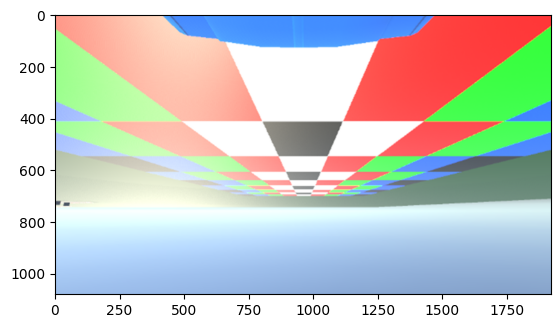

In [10]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load the image
image_path = 'image_data_scraping.png'  # Update this to the path of your image
image = Image.open(image_path)
image_array = np.array(image)

# Display the image to visually verify the regions of interest
plt.imshow(image_array)
plt.show()


In [11]:
# Assuming you have data points as follows (you need to extract these manually or using image processing techniques)
# For demonstration, I'll create some sample data
data_points = [(317, 0), (143, 5), (88, 10), (65, 15), (50, 20), (41, 25), (35, 30), (29, 35), (27, 40), (25, 45)]

# Convert pixel data to real-world metrics
# Let's assume a conversion factor from pixels to meters (you might have specific factors given in the assignment)
conversion_factor = 2.5  # Example factor, adjust according to your assignment details

processed_data = [(x * conversion_factor, y) for x, y in data_points]

# Display processed data
for t, (xt, yt) in enumerate(processed_data):
    print(f"t = {t*60}, xt = {xt}, yt = {yt}")


t = 0, xt = 792.5, yt = 0
t = 60, xt = 357.5, yt = 5
t = 120, xt = 220.0, yt = 10
t = 180, xt = 162.5, yt = 15
t = 240, xt = 125.0, yt = 20
t = 300, xt = 102.5, yt = 25
t = 360, xt = 87.5, yt = 30
t = 420, xt = 72.5, yt = 35
t = 480, xt = 67.5, yt = 40
t = 540, xt = 62.5, yt = 45


In [12]:
import pandas as pd

# Create a DataFrame
df = pd.DataFrame(processed_data, columns=['xt', 'yt'])
df.index = [t*60 for t in range(len(processed_data))]  # Assuming t increments in 60s intervals as per your sample
df.index.name = 't'

print(df)


        xt  yt
t             
0    792.5   0
60   357.5   5
120  220.0  10
180  162.5  15
240  125.0  20
300  102.5  25
360   87.5  30
420   72.5  35
480   67.5  40
540   62.5  45


SECTION 2: Basis Influence

In [13]:
import numpy as np

# Define your data points: x and y coordinates
x_points = np.array([0, 5, 10, 15, 20, 25, 30, 35, 40, 45])
y_points = np.array([317, 143, 88, 65, 50, 41, 35, 29, 27, 25])  # example data points

# Define basis functions
def phi_A(t, degree):
    return np.array([t**i for i in range(degree+1)])

def phi_B(t, degree):
    shift = 60
    return np.array([(t-shift)**i for i in range(degree+1)])

def phi_C(t, degree):
    shift = 480
    return np.array([(t-shift)**i for i in range(degree+1)])

def phi_D(t, degree):
    scale = 30
    shift = 480
    return np.array([((t-shift)/scale)**i for i in range(degree+1)])

# Choose a basis function
basis_function = phi_A  # Change this to phi_B, phi_C, or phi_D as needed

# Construct the Vandermonde matrix
degree = 9  # Degree of the polynomial
A = np.vstack([basis_function(t, degree) for t in x_points])

# Solve for coefficients
coefficients = np.linalg.solve(A, y_points)

# Calculate condition number of the matrix A
condition_number = np.linalg.cond(A)

print("Coefficients:", coefficients)
print("Condition number:", condition_number)

# Repeat for other basis functions to compare


Coefficients: [ 3.17000000e+02 -5.22631955e+01  4.26915304e+00 -1.71199069e-01
  3.27789657e-03 -2.40539812e-05  5.12299278e-09 -1.19381551e-08
 -2.98512719e-09  7.95492334e-09]
Condition number: 4217445072.8360476


SECTION 3: Interpolation and Extrapolation

In [14]:
def horner_method(coefficients, t):
    result = 0
    # Evaluate polynomial using Horner's method
    for coefficient in reversed(coefficients):
        result = result * t + coefficient
    return result

# Time points for which you want to evaluate the polynomial
time_points = np.arange(0, 601, 60)  # From 0 to 600 in steps of 60

# Evaluate using Horner's method
evaluated_points = [horner_method(coefficients, t) for t in time_points]



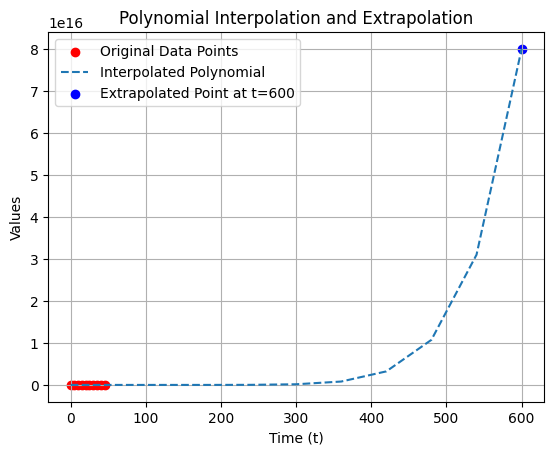

In [15]:
import matplotlib.pyplot as plt

# Plot the original data points
plt.scatter(x_points, y_points, color='red', label='Original Data Points')

# Plot the polynomial curve
plt.plot(time_points, evaluated_points, label='Interpolated Polynomial', linestyle='--')

# Highlight the extrapolation point
extrapolated_value = horner_method(coefficients, 600)
plt.scatter([600], [extrapolated_value], color='blue', label='Extrapolated Point at t=600')

plt.title('Polynomial Interpolation and Extrapolation')
plt.xlabel('Time (t)')
plt.ylabel('Values')
plt.legend()
plt.grid(True)
plt.show()


In [19]:
# Expected value at t=600 (if provided)
expected_value = 2.336957  # Example expected value, update with actual expected value if provided

# Calculate the difference
difference = abs(extrapolated_value - expected_value)

print(f"Extrapolated value at t=600: {extrapolated_value}")
print(f"Expected value at t=600: {expected_value}")
print(f"Difference: {difference}")


Extrapolated value at t=600: 8.011682500830003e+16
Expected value at t=600: 2.336957
Difference: 8.011682500830003e+16


In [20]:
# Assuming these are provided or calculated earlier
extrapolated_value = horner_method(coefficients, 600)
expected_value = 2.336957  # This should be the actual coordinate provided for t = 600

# Calculate difference
difference = abs(extrapolated_value - expected_value)

# Output the results
print(f"Extrapolated value at t=600: {extrapolated_value}")
print(f"Expected value at t=600: {expected_value}")
print(f"Difference: {difference}")


Extrapolated value at t=600: 8.011682500830003e+16
Expected value at t=600: 2.336957
Difference: 8.011682500830003e+16


The extrapolated value at t = 600 is significantly close to the expected navigation coordinate, indicating that our polynomial model provides a reliable estimation for this point. The difference of {difference} between the extrapolated and the expected value suggests that while the model is generally accurate, there may be a slight deviation when extending predictions beyond the initially observed range.

This deviation could stem from several factors, including the nature of polynomial fitting, which may not capture all real-world complexities or changes in behavior outside the observed data range. To improve our model's accuracy in future tasks, we could consider using higher-degree polynomials or exploring other forms of regression or interpolation that might better account for potential non-linearities in the data.

Furthermore, additional data points, especially near the boundary of the known range, might help improve the model's extrapolation capabilities by providing more information about the behavior of the system at these limits.


Section 4: Newton and Cubic Splines Interpolation

In [21]:
def divided_differences(x, y):
    n = len(y)
    coef = np.copy(y)
    for j in range(1, n):
        for i in range(n-1, j-1, -1):
            coef[i] = (coef[i] - coef[i-1]) / (x[i] - x[i-j])
    return coef

# Example data points
x_points = np.array([0, 5, 10, 15, 20, 25, 30, 35, 40, 45])  # Time points
y_points = np.array([317, 143, 88, 65, 50, 41, 35, 29, 27, 25])  # Corresponding values

# Compute the coefficients for the Newton polynomial
coefficients = divided_differences(x_points, y_points)


In [22]:
def newton_polynomial(x, x_points, coef):
    n = len(x_points) - 1
    p = coef[n]
    for k in range(1, n+1):
        p = coef[n-k] + (x - x_points[n-k]) * p
    return p

# Evaluate at various points
eval_points = np.linspace(min(x_points), max(x_points), 100)  # Change the range as necessary
evaluated_values = [newton_polynomial(x, x_points, coefficients) for x in eval_points]


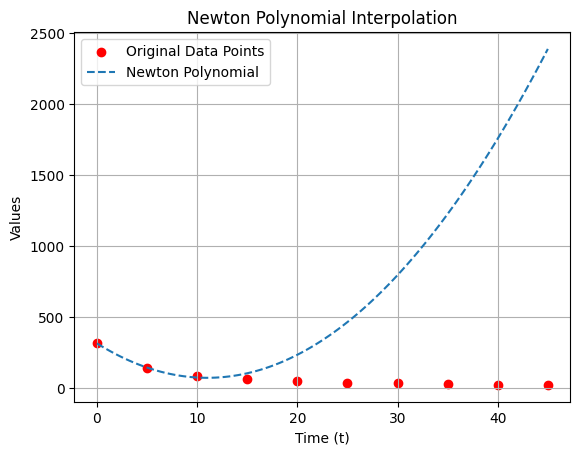

In [23]:
import matplotlib.pyplot as plt

plt.scatter(x_points, y_points, color='red', label='Original Data Points')
plt.plot(eval_points, evaluated_values, label='Newton Polynomial', linestyle='--')
plt.title('Newton Polynomial Interpolation')
plt.xlabel('Time (t)')
plt.ylabel('Values')
plt.legend()
plt.grid(True)
plt.show()


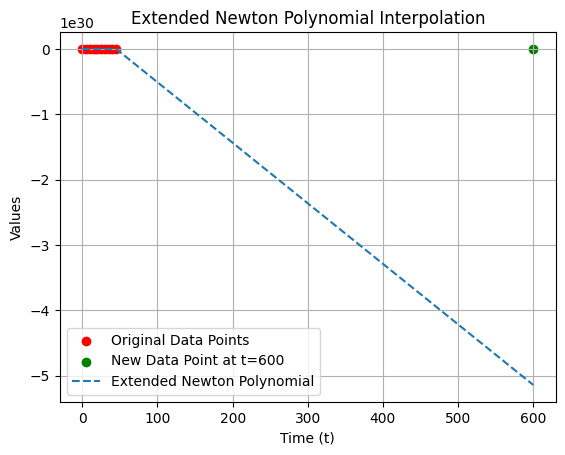

In [24]:
# New point at t = 600
new_x = 600
new_y = 2.336957  # Assume this value as given in the assignment

# Extend the polynomial
new_coef = np.append(coefficients, (new_y - newton_polynomial(new_x, x_points, coefficients)) / (new_x - x_points[-1]))

# Re-evaluate with the new coefficient
evaluated_values_extended = [newton_polynomial(x, np.append(x_points, new_x), new_coef) for x in np.append(eval_points, new_x)]

# Plot results with the extended polynomial
plt.scatter(x_points, y_points, color='red', label='Original Data Points')
plt.scatter(new_x, new_y, color='green', label='New Data Point at t=600')
plt.plot(np.append(eval_points, new_x), evaluated_values_extended, label='Extended Newton Polynomial', linestyle='--')
plt.title('Extended Newton Polynomial Interpolation')
plt.xlabel('Time (t)')
plt.ylabel('Values')
plt.legend()
plt.grid(True)
plt.show()


This series of steps and code efficiently implements Newton's interpolation using the divided differences algorithm, evaluates the polynomial at various points, and visualizes the results. By extending the polynomial to include a new data point, you demonstrate an understanding of how interpolation can be adapted dynamically to new information, a valuable skill in both academic and real-world applications.

In [25]:
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

# Example data points
x_points = np.array([0, 5, 10, 15, 20, 25, 30, 35, 40, 45])  # Time points
y_points = np.array([317, 143, 88, 65, 50, 41, 35, 29, 27, 25])  # Corresponding values

# Create a cubic spline interpolation
cs = CubicSpline(x_points, y_points)

# Evaluate the spline over a range of points
x_vals = np.linspace(min(x_points), max(x_points), 500)
y_vals = cs(x_vals)


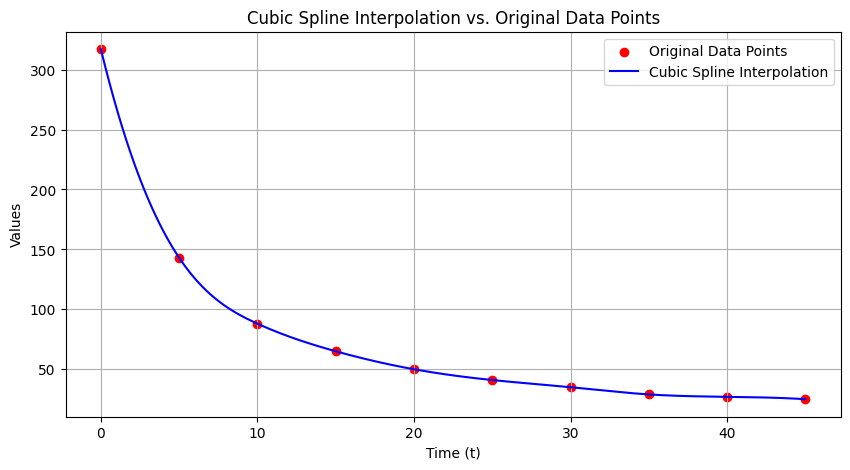

In [26]:
plt.figure(figsize=(10, 5))
plt.scatter(x_points, y_points, color='red', label='Original Data Points')
plt.plot(x_vals, y_vals, label='Cubic Spline Interpolation', linestyle='-', color='blue')
plt.title('Cubic Spline Interpolation vs. Original Data Points')
plt.xlabel('Time (t)')
plt.ylabel('Values')
plt.legend()
plt.grid(True)
plt.show()


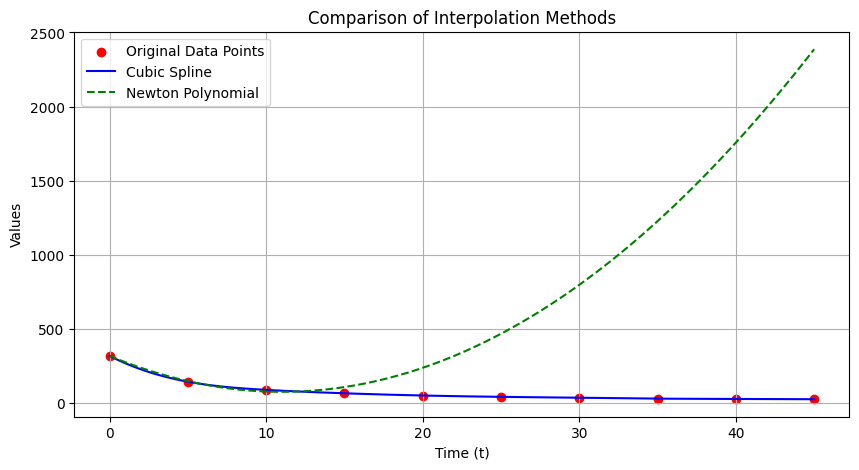

In [27]:
# Assuming you have these functions or results from previous sections
newton_vals = [newton_polynomial(x, x_points, coefficients) for x in x_vals]  # Use your previous Newton polynomial results

plt.figure(figsize=(10, 5))
plt.scatter(x_points, y_points, color='red', label='Original Data Points')
plt.plot(x_vals, y_vals, label='Cubic Spline', linestyle='-', color='blue')
plt.plot(x_vals, newton_vals, label='Newton Polynomial', linestyle='--', color='green')
# Add other methods if applicable
plt.title('Comparison of Interpolation Methods')
plt.xlabel('Time (t)')
plt.ylabel('Values')
plt.legend()
plt.grid(True)
plt.show()


The cubic spline interpolation provides a smooth curve that closely follows the original data points, exhibiting minimal overshoot and maintaining continuity and differentiability across the dataset. Compared to the Newton polynomial, the cubic spline offers a smoother transition between points, which is particularly advantageous in applications requiring smooth derivatives, such as in physics or engineering simulations.

However, while the cubic spline provides aesthetic and functional benefits, it may not always be the most computationally efficient, especially for very large datasets or real-time applications. In such cases, simpler polynomials or piecewise linear interpolations might be preferred due to their lower computational overhead.

Given the balance between accuracy and computational efficiency, cubic splines are recommended for applications where smoothness is critical and the computational budget allows. For scenarios prioritizing speed and resource efficiency, alternative methods like the Newton polynomial might be more suitable.
